### IMPORT LIBRARIES

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2

from PIL import Image

from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

### REBUILD MOBILENETV2

In [2]:
base_model = MobileNetV2(
    include_top=False,
    weights="imagenet",
    input_shape=(224,224,3)
)

base_model.trainable = False

x = layers.GlobalAveragePooling2D()(base_model.output)

x = layers.BatchNormalization()(x)

x = layers.Dense(128, activation='relu')(x)

x = layers.Dropout(0.4)(x)

output = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(
    inputs=base_model.input,
    outputs=output
)

### LOAD SAVED WEIGHTS

In [3]:
model.load_weights(
    r"C:\Users\HP PC\Data_Science\Medical_Imaging\Peadiatric_ChesRay_App\mobilenetv2_pneumonia_weights.h5"
)

print("Weights loaded successfully")

Weights loaded successfully


### VERIFY MODEL

In [4]:
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 Conv1 (Conv2D)                 (None, 112, 112, 32  864         ['input_1[0][0]']                
                                )                                                                 
                                                                                                  
 bn_Conv1 (BatchNormalization)  (None, 112, 112, 32  128         ['Conv1[0][0]']                  
                                )                                                             

### FIND LAST CONVOLUTION LAYER

Very important for Grad-CAM.

In [5]:
for layer in model.layers:
    print(layer.name)

input_1
Conv1
bn_Conv1
Conv1_relu
expanded_conv_depthwise
expanded_conv_depthwise_BN
expanded_conv_depthwise_relu
expanded_conv_project
expanded_conv_project_BN
block_1_expand
block_1_expand_BN
block_1_expand_relu
block_1_pad
block_1_depthwise
block_1_depthwise_BN
block_1_depthwise_relu
block_1_project
block_1_project_BN
block_2_expand
block_2_expand_BN
block_2_expand_relu
block_2_depthwise
block_2_depthwise_BN
block_2_depthwise_relu
block_2_project
block_2_project_BN
block_2_add
block_3_expand
block_3_expand_BN
block_3_expand_relu
block_3_pad
block_3_depthwise
block_3_depthwise_BN
block_3_depthwise_relu
block_3_project
block_3_project_BN
block_4_expand
block_4_expand_BN
block_4_expand_relu
block_4_depthwise
block_4_depthwise_BN
block_4_depthwise_relu
block_4_project
block_4_project_BN
block_4_add
block_5_expand
block_5_expand_BN
block_5_expand_relu
block_5_depthwise
block_5_depthwise_BN
block_5_depthwise_relu
block_5_project
block_5_project_BN
block_5_add
block_6_expand
block_6_expand

### BUILD GRAD-CAM MODEL

In [6]:
grad_model = tf.keras.models.Model(
    [model.inputs],
    [
        model.get_layer("Conv_1").output,
        model.output
    ]
)

### Recreate img_array

In [9]:
img_path = r"C:\Users\HP PC\Downloads\test\PNEUMONIA\person100_bacteria_475.jpeg"

img = Image.open(img_path).convert("RGB")

img = img.resize((224,224))

img_array = np.array(img)

img_array = np.expand_dims(img_array, axis=0)

img_array = preprocess_input(img_array)

In [11]:
print(img_array.shape)

(1, 224, 224, 3)


### COMPUTE GRADIENTS

In [10]:
with tf.GradientTape() as tape:

    conv_outputs, predictions = grad_model(img_array)

    loss = predictions[:, 0]

# Compute gradients
grads = tape.gradient(loss, conv_outputs)

### GLOBAL AVERAGE THE GRADIENTS

In [12]:
pooled_grads = tf.reduce_mean(
    grads,
    axis=(0, 1, 2)
)

### REMOVE BATCH DIMENSION

In [13]:
conv_outputs = conv_outputs[0]

### CREATE HEATMAP

In [14]:
heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]

heatmap = tf.squeeze(heatmap)

### NORMALIZE HEATMAP

In [15]:
heatmap = np.maximum(heatmap, 0)

heatmap /= np.max(heatmap)

### CHECK SHAPE

In [16]:
print(heatmap.shape)

(7, 7)


### DISPLAY HEATMAP

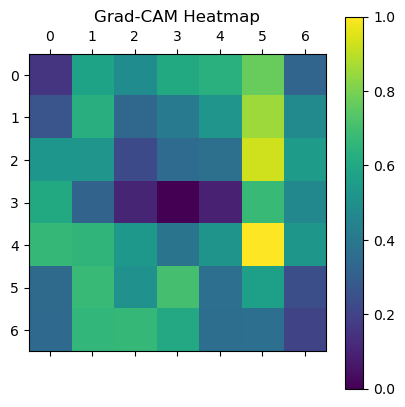

In [17]:
plt.matshow(heatmap)

plt.title("Grad-CAM Heatmap")

plt.colorbar()

plt.show()

### let us do the overlay LOAD ORIGINAL IMAGE AGAIN


In [18]:
original_img = cv2.imread(img_path)

original_img = cv2.cvtColor(
    original_img,
    cv2.COLOR_BGR2RGB
)

original_img = cv2.resize(
    original_img,
    (224,224)
)

### RESIZE HEATMAP

Currently your heatmap is tiny (like 7×7).

Resize it to full image size:

In [20]:
heatmap_resized = cv2.resize(
    heatmap,
    (224,224)
)

In [21]:
heatmap_uint8 = np.uint8(
    255 * heatmap_resized
)

### APPLY COLORMAP

In [22]:
heatmap_color = cv2.applyColorMap(
    heatmap_uint8,
    cv2.COLORMAP_JET
)

### OVERLAY HEATMAP ON X-RAY

In [23]:
superimposed_img = cv2.addWeighted(
    original_img,
    0.6,
    heatmap_color,
    0.4,
    0
)

### DISPLAY FINAL RESULT

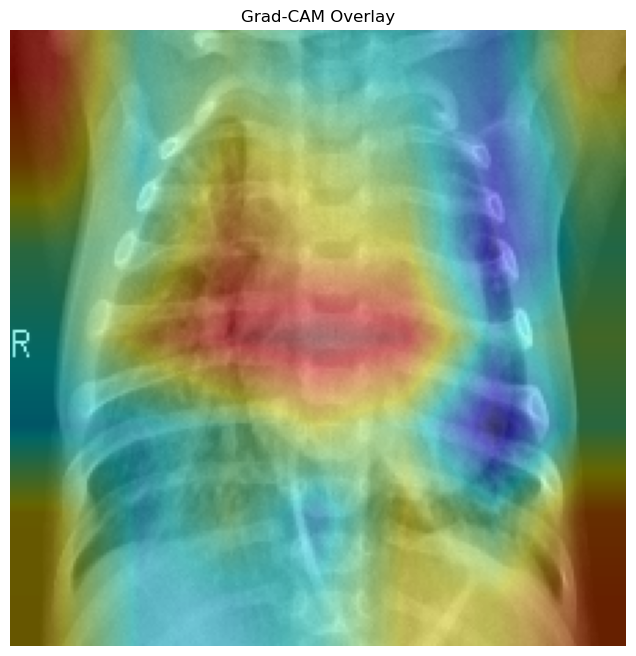

In [24]:
plt.figure(figsize=(8,8))

plt.imshow(superimposed_img)

plt.axis("off")

plt.title("Grad-CAM Overlay")

plt.show()

### 🧠 This is now a strong explainability result

You can now say your project includes:

* Capability	Status
* Classification	✅
* Threshold calibration	✅
* Explainability	✅
* Clinical attention visualization	✅

That elevates the project significantly.

### Does the model behave reasonably on NORMAL lungs?

This helps explain:

* false positives
* over-sensitivity
* model attention behavior

### CHANGE IMAGE PATH

Replace your pneumonia image path with a NORMAL image.

In [25]:
img_path = r"C:\Users\HP PC\Downloads\test\NORMAL\NORMAL2-IM-1427-0001.jpeg"

### RERUN IMAGE PREPROCESSING

### Let us inspect the normal images in the test dataset

In [27]:
import os

normal_path = r"C:\Users\HP PC\Downloads\test\NORMAL"

print(os.listdir(normal_path)[:10])

['IM-0001-0001.jpeg', 'IM-0003-0001.jpeg', 'IM-0005-0001.jpeg', 'IM-0006-0001.jpeg', 'IM-0007-0001.jpeg', 'IM-0009-0001.jpeg', 'IM-0010-0001.jpeg', 'IM-0011-0001-0001.jpeg', 'IM-0011-0001-0002.jpeg', 'IM-0011-0001.jpeg']


In [28]:
img_path = r"C:\Users\HP PC\Downloads\test\NORMAL\IM-0001-0001.jpeg"

### Then rerun preprocessing

In [29]:
img = Image.open(img_path).convert("RGB")

img = img.resize((224,224))

img_array = np.array(img)

img_array = np.expand_dims(img_array, axis=0)

img_array = preprocess_input(img_array)

### Then prediction

In [30]:
prediction = model.predict(img_array)[0][0]

print("Pneumonia Probability:", prediction)

1/1 [==============================] - 1s 880ms/step
Pneumonia Probability: 0.37606984


### GradientTape

In [31]:
with tf.GradientTape() as tape:

    conv_outputs, predictions = grad_model(img_array)

    loss = predictions[:, 0]

grads = tape.gradient(loss, conv_outputs)

### Pool gradients

In [32]:
pooled_grads = tf.reduce_mean(
    grads,
    axis=(0,1,2)
)

### Remove batch dimension

In [33]:
conv_outputs = conv_outputs[0]

### Generate heatmap

In [34]:
heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]

heatmap = tf.squeeze(heatmap)

### Normalize heatmap

In [35]:
heatmap = np.maximum(heatmap, 0)

heatmap /= np.max(heatmap)

### Reload original image

In [36]:
original_img = cv2.imread(img_path)

original_img = cv2.cvtColor(
    original_img,
    cv2.COLOR_BGR2RGB
)

original_img = cv2.resize(
    original_img,
    (224,224)
)

### Resize heatmap

In [37]:
heatmap_resized = cv2.resize(
    heatmap,
    (224,224)
)

### Convert to uint8

In [38]:
heatmap_uint8 = np.uint8(
    255 * heatmap_resized
)

### Apply color map

In [39]:
heatmap_color = cv2.applyColorMap(
    heatmap_uint8,
    cv2.COLORMAP_JET
)

### Overlay heatmap

In [40]:
superimposed_img = cv2.addWeighted(
    original_img,
    0.6,
    heatmap_color,
    0.4,
    0
)

### Display final overlay

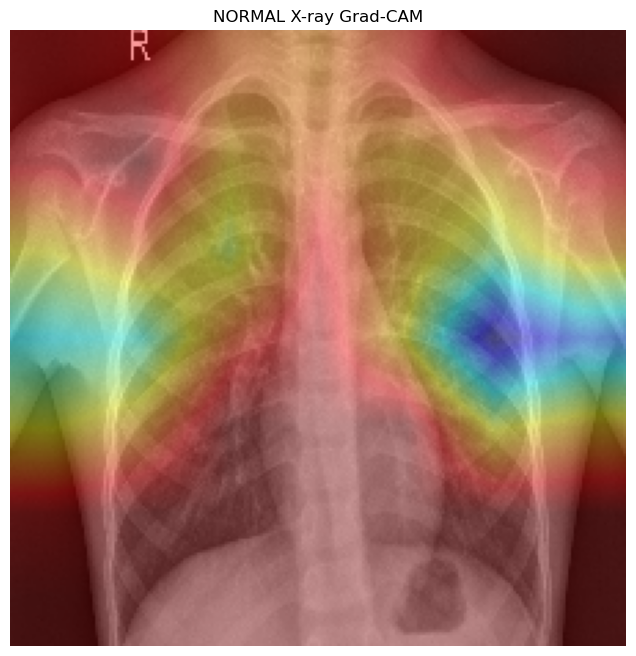

In [41]:
plt.figure(figsize=(8,8))

plt.imshow(superimposed_img)

plt.axis("off")

plt.title("NORMAL X-ray Grad-CAM")

plt.show()